In [1]:
!pip install torch
!pip install transformers
!pip install tqdm

In [2]:
import torch
from torch import nn
from transformers import BertTokenizer, BertModel
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from tqdm import tqdm
from transformers import get_scheduler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [3]:
torch.manual_seed(42)

device = (
    "mps"
    if torch.backends.mps.is_available()
    else "cuda"
    if torch.cuda.is_available()
    else "cpu"
)
device = torch.device(device)
print(f"Using device: {device}")

Using device: cuda


In [4]:
sentences = "C:/Users/zhoum/Downloads/DSA4265_Project/Results/sentence_data/sentences.csv"

In [5]:
df_all = pd.read_excel("/content/labelled_sentences.xlsx")
df_all = df_all.rename(columns={"Sentiment": "sentiment", "Topic ": "topic"})


df_all_labeled = df_all[df_all["sentiment"].notna() & df_all["topic"].notna()].copy()
df_all_unlabeled = df_all[~(df_all["sentiment"].notna() & df_all["topic"].notna())].copy()


df_train, df_test = train_test_split(
    df_all_labeled,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=df_all_labeled["sentiment"]
)

print(f"Training labeled rows shape: {df_train.shape}")
print(f"Testing set shape: {df_test.shape}")
print(f"Unlabeled rows shape: {df_all_unlabeled.shape}")

Training labeled rows shape: (1470, 8)
Testing set shape: (368, 8)
Unlabeled rows shape: (1701, 8)


In [6]:
df=df_train

In [7]:
sentiment_map = {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2
}

df["sentiment_label"] = df["sentiment"].map(sentiment_map)

In [8]:
topics = ["Growth", "Risk", "Outlook", "Operation","General"]

topic_map = {"Growth":0, "Risk":1, "Outlook":2, "Operation":3, "General":4}
df["topic_label"] = df["topic"].map(topic_map)

In [9]:
df.shape

(1470, 10)

In [10]:
sentiment_labels=df["sentiment_label"].values
sentiment_classes=np.unique(sentiment_labels)
sentiment_weights=compute_class_weight(
    class_weight="balanced",
    classes=sentiment_classes,
    y=sentiment_labels
)
sentiment_weights=torch.tensor(sentiment_weights,dtype=torch.float).to(device)


topic_labels=df["topic_label"].values
topic_classes=np.unique(topic_labels)
topic_weights=compute_class_weight(
    class_weight="balanced",
    classes=topic_classes,
    y=topic_labels
)
topic_weights=torch.tensor(topic_weights,dtype=torch.float).to(device)

In [11]:
from datasets import Dataset
from transformers import AutoTokenizer

dataset = Dataset.from_pandas(df)

model_name = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(example):
    return tokenizer(example["sentence"], truncation=True, padding="max_length")

dataset = dataset.map(tokenize)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/1470 [00:00<?, ? examples/s]

In [12]:
dataset

Dataset({
    features: ['company', 'quarter', 'year', 'sentence_id', 'speaker', 'sentence', 'sentiment', 'topic', 'sentiment_label', 'topic_label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1470
})

In [13]:
import torch
import torch.nn as nn
from transformers import AutoModel
class MultiTaskModel(nn.Module):
    def __init__(self,model_name):
        super().__init__()
        self.bert=AutoModel.from_pretrained(model_name)
        hidden=self.bert.config.hidden_size

        self.sentiment_head=nn.Linear(hidden,3)
        self.topic_head=nn.Linear(hidden,5)

    def forward(self,input_ids,attention_mask,sentiment_label=None,topic_label=None):
        outputs=self.bert(input_ids=input_ids,attention_mask=attention_mask)
        pooled=outputs.pooler_output

        sentiment_logits=self.sentiment_head(pooled)
        topic_logits=self.topic_head(pooled)

        loss=None
        if sentiment_label is not None:
            ce_loss=nn.CrossEntropyLoss(weight=sentiment_weights)(sentiment_logits,sentiment_label)
            topic_loss = nn.CrossEntropyLoss(weight=topic_weights)(topic_logits, topic_label)
            loss=ce_loss+topic_loss
        return{
            "loss":loss,
            "sentiment_logits":sentiment_logits,
            "topic_logits":topic_logits
        }

In [14]:
from transformers import TrainingArguments, Trainer

def collate_fn(batch):
    return {
        "input_ids": torch.tensor([x["input_ids"] for x in batch]),
        "attention_mask": torch.tensor([x["attention_mask"] for x in batch]),
        "sentiment_label": torch.tensor([x["sentiment_label"] for x in batch]),
        "topic_label": torch.tensor([x["topic_label"] for x in batch]),

    }
model=MultiTaskModel(model_name)
for param in model.bert.parameters():
    param.requires_grad = False

training_args=TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=8,
    num_train_epochs=3,
    learning_rate=2e-5
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
    data_collator=collate_fn
)

trainer.train()



pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.bias              | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Step,Training Loss
500,2.465604


TrainOutput(global_step=552, training_loss=2.4436449797257134, metrics={'train_runtime': 35.8811, 'train_samples_per_second': 122.906, 'train_steps_per_second': 15.384, 'total_flos': 0.0, 'train_loss': 2.4436449797257134, 'epoch': 3.0})

In [15]:
import torch.nn.functional as F

def predict(text):
    model.eval()

    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    inputs.pop("token_type_ids", None)

    device = next(model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    sent_probs = torch.softmax(outputs["sentiment_logits"], dim=1)
    sent_conf, sent_idx = torch.max(sent_probs, dim=1)

    topic_probs = torch.softmax(outputs["topic_logits"], dim=1)
    topic_conf, topic_idx = torch.max(topic_probs, dim=1)

    sentiment_inv = {0: "Negative", 1: "Neutral", 2: "Positive"}
    topics = ["Growth", "Risk", "Outlook", "Operation","General"]

    return {
        "sentiment": sentiment_inv[sent_idx.item()],
        "sent_conf": sent_conf.item(),
        "topic": topics[topic_idx.item()],
        "topic_conf": topic_conf.item()
    }

In [16]:
predict("The company is suffering from loss.")

{'sentiment': 'Negative',
 'sent_conf': 0.7125377058982849,
 'topic': 'Risk',
 'topic_conf': 0.4345759451389313}

In [17]:
filtered_results = []
filtered_indices = []
for i,text in enumerate(tqdm(df_all_unlabeled["sentence"])):
    pred=predict(text)

    if pred['sent_conf']>0.7 and pred["topic_conf"]>0.7:
        filtered_results.append(pred)
        filtered_indices.append(i)


df_filtered_unlabeled=df_all_unlabeled.iloc[filtered_indices].copy()

num_filtered = len(df_filtered_unlabeled)
print(num_filtered)



100%|██████████| 1701/1701 [00:15<00:00, 106.76it/s]

0


In [18]:
df_filtered_unlabeled["sentiment"] = [r["sentiment"] for r in filtered_results]
df_filtered_unlabeled["topic"] = [r["topic"] for r in filtered_results]
print(df_filtered_unlabeled.shape)
print(df_filtered_unlabeled.tail(10))
print(f"Kept {len(df_filtered_unlabeled)} out of {len(df_all_unlabeled)} samples")

(0, 8)
Empty DataFrame
Columns: [company, quarter, year, sentence_id, speaker, sentence, sentiment, topic]
Index: []
Kept 0 out of 1701 samples


In [19]:
df_all_labeled.head()

,company,quarter,year,sentence_id,speaker,sentence,sentiment,topic
0,amazon,Q3,2025,0,Dave Fildes,"Hello, and welcome to our Q3 2025 financial re...",Neutral,General
1,amazon,Q3,2025,1,Dave Fildes,Joining us today to answer your questions is A...,Neutral,General
2,amazon,Q3,2025,2,Dave Fildes,"As you listen to today's conference call, we e...",Neutral,General
3,amazon,Q3,2025,3,Dave Fildes,"Please note, unless otherwise stated.",Neutral,General
4,amazon,Q3,2025,4,Dave Fildes,All comparisons in this call will be against o...,Neutral,General


In [20]:


df_unlabeled_clean = df_filtered_unlabeled[['company', 'quarter', 'year',
                                'sentence_id', 'speaker', 'sentence',
                                   'sentiment', 'topic' ]].copy()


df_labeled_clean = df_train[['company', 'quarter', 'year',
                                'sentence_id', 'speaker', 'sentence',
                               'sentiment', 'topic']].copy()


df_full = pd.concat([df_labeled_clean, df_unlabeled_clean], ignore_index=True)



print(df_full.head())
print(df_full.shape)

  company quarter  year  sentence_id            speaker  \
0  amazon      Q4  2025           12        Dave Fildes   
1  amazon      Q4  2025           79  Brian T. Olsavsky   
2  amazon      Q3  2025           24     Brian Olsavsky   
3  amazon      Q4  2025           57       Andrew Jassy   
4   tesla      Q4  2025            7          Elon Musk   

                                            sentence sentiment    topic  
0  It's not possible to accurately predict demand...  Negative     Risk  
1  I want to thank everyone across the company fo...  Positive  General  
2  Excluding the $2.5 billion charge related to t...  Positive   Growth  
3  It is a multibillion-dollar annualized revenue...  Positive   Growth  
4                         A rare earth ore refinery.   Neutral  General  
(1470, 8)


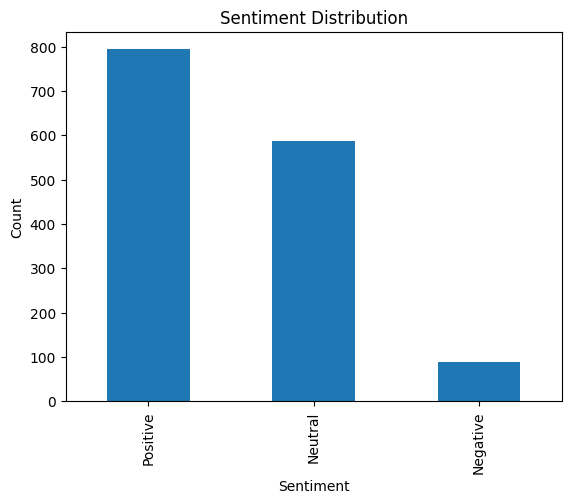

In [21]:
df_full['sentiment'].value_counts().plot(kind='bar')

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()


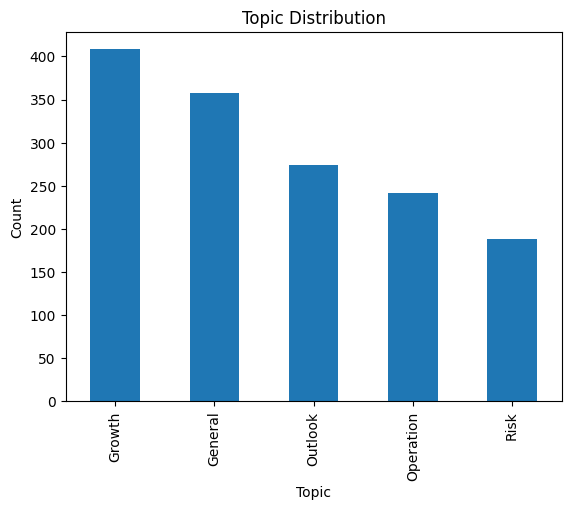

In [22]:
df_full['topic'].value_counts().plot(kind='bar')

plt.title('Topic Distribution')
plt.xlabel('Topic')
plt.ylabel('Count')
plt.show()

In [23]:
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset as TorchDataset, DataLoader



df_full["sentiment_label"] = df_full["sentiment"].map(sentiment_map)

df_full["topic_label"] = df_full["topic"].map(topic_map)
df_full["year"] = pd.to_numeric(df_full["year"], errors="coerce")

df_test["sentiment_label"] = df_test["sentiment"].map(sentiment_map)
df_test["topic_label"] = df_test["topic"].map(topic_map)
df_test["year"] = pd.to_numeric(df_test["year"], errors="coerce")




model_name = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_batch(batch):
    return tokenizer(
        batch["sentence"],
        truncation=True,
        padding="max_length",
        max_length=128,
    )


train_hf = Dataset.from_pandas(df_full).map(tokenize_batch, batched=True)
test_hf = Dataset.from_pandas(df_test).map(tokenize_batch, batched=True)

class MultiTaskDataset(TorchDataset):
    def __init__(self, hf_dataset):
        self.dataset = hf_dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        return {
            "input_ids": torch.tensor(item["input_ids"], dtype=torch.long),
            "attention_mask": torch.tensor(item["attention_mask"], dtype=torch.long),
            "sentiment_label": torch.tensor(item["sentiment_label"], dtype=torch.long),
            "topic_label": torch.tensor(item["topic_label"], dtype=torch.long),
        }


train_dataset = MultiTaskDataset(train_hf)
test_dataset = MultiTaskDataset(test_hf)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)



Map:   0%|          | 0/1470 [00:00<?, ? examples/s]

Map:   0%|          | 0/368 [00:00<?, ? examples/s]

In [24]:
for i in range(len(train_dataset)):
    item = train_dataset.dataset[i]  # underlying HF dataset
    if item["sentiment_label"] is None or item["topic_label"] is None:
        print(f"Missing labels at index {i}: {item}")

In [25]:
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)
num_epochs = 3
num_training_steps = num_epochs * len(train_loader)
scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps
)

# ----- Training Loop -----
for epoch in range(num_epochs):

    if epoch==1:
        print("Unfreezing last 2 BERT layers ...")
        for layer in model.bert.encoder.layer[-2:]:
            for param in layer.parameters():
                param.requires_grad=True

        optimizer=AdamW(filter(lambda p: p.requires_grad,model.parameters()),lr=1e-5)
    if epoch==2:
        print("Unfreezing last 4 layers ...")
        for param in model.bert.encoder.layer[-4:]:
            param.requires_grad=True

        optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=5e-6)


    model.train()
    total_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    for batch in progress_bar:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        sentiment_labels = batch["sentiment_label"].to(device)
        topic_labels = batch["topic_label"].to(device)

        outputs = model(input_ids, attention_mask, sentiment_labels, topic_labels)
        loss = outputs["loss"]

        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        progress_bar.set_postfix({"loss": f"{total_loss / (progress_bar.n + 1):.4f}"})

    print(f"Epoch {epoch+1} finished | Avg Train Loss: {total_loss / len(train_loader):.4f}")

# ----- Evaluation -----
model.eval()
correct_sentiment, correct_topic, total = 0, 0, 0
all_sentiment_preds=[]
all_sentiment_labels=[]

all_topic_preds=[]
all_topic_labels=[]

with torch.no_grad():
    progress_bar = tqdm(test_loader, desc="Evaluating")
    for batch in progress_bar:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        sentiment_labels = batch["sentiment_label"].to(device)
        topic_labels = batch["topic_label"].to(device)

        outputs = model(input_ids, attention_mask)
        sentiment_logits = outputs["sentiment_logits"]
        topic_logits = outputs["topic_logits"]

        sentiment_preds=sentiment_logits.argmax(dim=1)
        topic_preds=topic_logits.argmax(dim=1)

        all_sentiment_preds.extend(sentiment_preds.cpu().numpy())
        all_sentiment_labels.extend(sentiment_labels.cpu().numpy())

        all_topic_preds.extend(topic_preds.cpu().numpy())
        all_topic_labels.extend(topic_labels.cpu().numpy())

        correct_sentiment += (sentiment_logits.argmax(dim=1) == sentiment_labels).sum().item()
        correct_topic += (topic_logits.argmax(dim=1) == topic_labels).sum().item()
        total += input_ids.size(0)

print(f"Sentiment Accuracy: {correct_sentiment / total:.4f}")
print(f"Topic Accuracy: {correct_topic / total:.4f}")
print("\nSentiment Results:")
print("Accuracy:", accuracy_score(all_sentiment_labels, all_sentiment_preds))
print(classification_report(
    all_sentiment_labels,
    all_sentiment_preds,
    target_names=["Negative", "Neutral", "Positive"]
))

print("\nTopic Results:")
print("Accuracy:", accuracy_score(all_topic_labels, all_topic_preds))
print(classification_report(
    all_topic_labels,
    all_topic_preds,
    target_names=["Growth", "Risk", "Outlook", "Operation", "General"]
))

Epoch 1/3: 100%|██████████| 92/92 [00:03<00:00, 28.49it/s, loss=2.3297]


Epoch 1 finished | Avg Train Loss: 2.3297
Unfreezing last 2 BERT layers ...


Epoch 2/3: 100%|██████████| 92/92 [00:03<00:00, 23.62it/s, loss=2.2205]


Epoch 2 finished | Avg Train Loss: 2.1722
Unfreezing last 4 layers ...


Epoch 3/3: 100%|██████████| 92/92 [00:03<00:00, 23.71it/s, loss=2.0848]


Epoch 3 finished | Avg Train Loss: 2.0621


Evaluating: 100%|██████████| 23/23 [00:00<00:00, 29.86it/s]

Sentiment Accuracy: 0.7038
Topic Accuracy: 0.4810

Sentiment Results:
Accuracy: 0.7038043478260869
              precision    recall  f1-score   support

    Negative       0.28      0.68      0.39        22
     Neutral       0.74      0.54      0.63       147
    Positive       0.80      0.82      0.81       199

    accuracy                           0.70       368
   macro avg       0.60      0.68      0.61       368
weighted avg       0.74      0.70      0.71       368


Topic Results:
Accuracy: 0.48097826086956524
              precision    recall  f1-score   support

      Growth       0.50      0.68      0.58       100
        Risk       0.54      0.63      0.58        52
     Outlook       0.25      0.25      0.25        69
   Operation       0.31      0.08      0.13        62
     General       0.61      0.64      0.62        85

    accuracy                           0.48       368
   macro avg       0.44      0.46      0.43       368
weighted avg       0.45      0.48      0

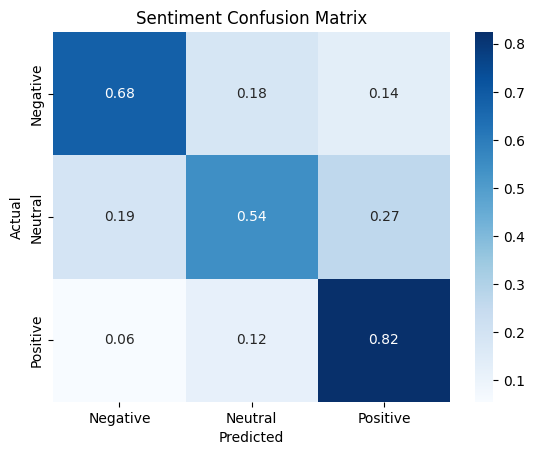

In [26]:
cm = confusion_matrix(all_sentiment_labels, all_sentiment_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, None]

plt.figure()
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Sentiment Confusion Matrix")
plt.show()

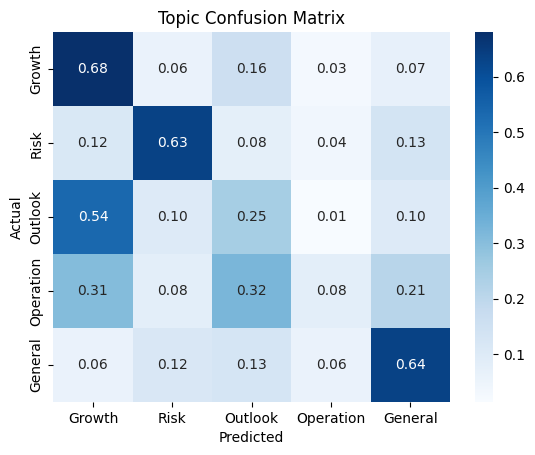

In [27]:
cm = confusion_matrix(all_topic_labels, all_topic_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, None]
plt.figure()
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=["Growth", "Risk", "Outlook", "Operation", "General"],
    yticklabels=["Growth", "Risk", "Outlook", "Operation", "General"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Topic Confusion Matrix")
plt.show()